In [111]:
# model size reduxcing 

import tensorflow as tf

# Load your Keras model
model = tf.keras.models.load_model("traffic_sign_mobilenetv2.h5")

# Create a TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# -----------------------------
# Quantization for size reduction
# -----------------------------
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Optional: Full integer quantization
# Requires representative dataset generator
def representative_dataset():
    # Use a small subset of your training data
    for cls in os.listdir("traffic_sign_dataset/train"):
        cls_folder = os.path.join("traffic_sign_dataset/train", cls)
        for i, f in enumerate(os.listdir(cls_folder)):
            if i >= 5:  # take first 5 images per class
                break
            img_path = os.path.join(cls_folder, f)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = tf.expand_dims(img_array, 0)
            img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
            yield [img_array]

converter.representative_dataset = representative_dataset

# Use integer quantization for further size reduction
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

# Convert the model
tflite_model = converter.convert()

# Save the TFLite model
with open("traffic_sign_model_optimized.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved! Check size:", round(os.path.getsize("traffic_sign_model_optimized.tflite")/1e6, 2), "MB")

INFO:tensorflow:Assets written to: /tmp/tmpj6m_nd8v/assets


INFO:tensorflow:Assets written to: /tmp/tmpj6m_nd8v/assets


Saved artifact at '/tmp/tmpj6m_nd8v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 36), dtype=tf.float32, name=None)
Captures:
  134541830733264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523144400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523144592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134541830732112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523143824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523143440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523144208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523144016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523144976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523145168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134539523133

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772173955.189333      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772173955.189365      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ TFLite model saved! Check size: 3.06 MB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [101]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [88]:
IMG_SIZE = (224,224)  # MobileNetV2 prefers 224x224
BATCH_SIZE = 32

In [89]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 315 images belonging to 36 classes.


In [91]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=False
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [92]:
num_classes = train_generator.num_classes
print("Number of classes:", num_classes)

Number of classes: 36


In [83]:
train_generator = train_datagen.flow_from_directory(
    "/kaggle/working/traffic_sign_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/kaggle/working/traffic_sign_dataset/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    "/kaggle/working/traffic_sign_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 315 images belonging to 36 classes.
Found 69 images belonging to 36 classes.
Found 151 images belonging to 36 classes.


In [93]:
num_classes = train_generator.num_classes

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze the base model
base_model.trainable = False

# Add custom classifier on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [94]:
model.compile( optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,172 (9.90 MB)

 Trainable params: 337,188 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [97]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20  
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 457ms/step - accuracy: 0.5972 - loss: 1.7917 - val_accuracy: 0.7681 - val_loss: 1.2252
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 430ms/step - accuracy: 0.5251 - loss: 1.8502 - val_accuracy: 0.7826 - val_loss: 1.1946
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 415ms/step - accuracy: 0.6194 - loss: 1.6431 - val_accuracy: 0.7826 - val_loss: 1.1644
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 421ms/step - accuracy: 0.6038 - loss: 1.6590 - val_accuracy: 0.7971 - val_loss: 1.1359
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 422ms/step - accuracy: 0.6364 - loss: 1.6409 - val_accuracy: 0.7826 - val_loss: 1.1080
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 431ms/step - accuracy: 0.6379 - loss: 1.5854 - val_accuracy: 0.7971 - val_loss: 1.0809
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.6341 - loss: 1.4842 - val_accuracy: 0.7971 - val_loss: 1.0532
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 420ms/step - accuracy: 0.6545 - loss: 1.5369 - val_accuracy: 0.

In [98]:
base_model.trainable = True

# Freeze first few layers (to prevent overfitting)
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7647 - loss: 1.0880 - val_accuracy: 0.8261 - val_loss: 0.7603
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - accuracy: 0.7576 - loss: 1.0411 - val_accuracy: 0.8261 - val_loss: 0.7426
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 408ms/step - accuracy: 0.7943 - loss: 1.0090 - val_accuracy: 0.8261 - val_loss: 0.7233
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 424ms/step - accuracy: 0.7942 - loss: 0.9652 - val_accuracy: 0.8261 - val_loss: 0.7032
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - accuracy: 0.8127 - loss: 0.9652 - val_accuracy: 0.8551 - val_loss: 0.6830
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 425ms/step - accuracy: 0.8502 - loss: 0.8767 - val_accuracy: 0.8551 - val_loss: 0.6645
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 416ms/step - accuracy: 0.8393 - loss: 0.8774 - val_accuracy: 0.8696 - val_loss: 0.6467
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 409ms/step - accuracy: 0.7820 - loss: 0.8758 - val_accuracy: 0.86

In [100]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.7967 - loss: 0.8862
Test Accuracy: 0.8211920261383057


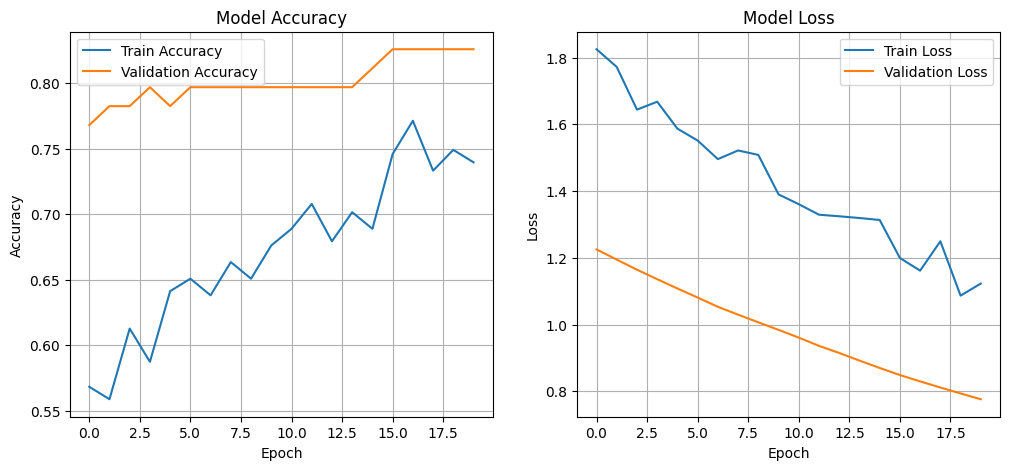

In [102]:
# Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

2026-02-27 06:05:21.215303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 06:05:21.368421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 06:05:21.502602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


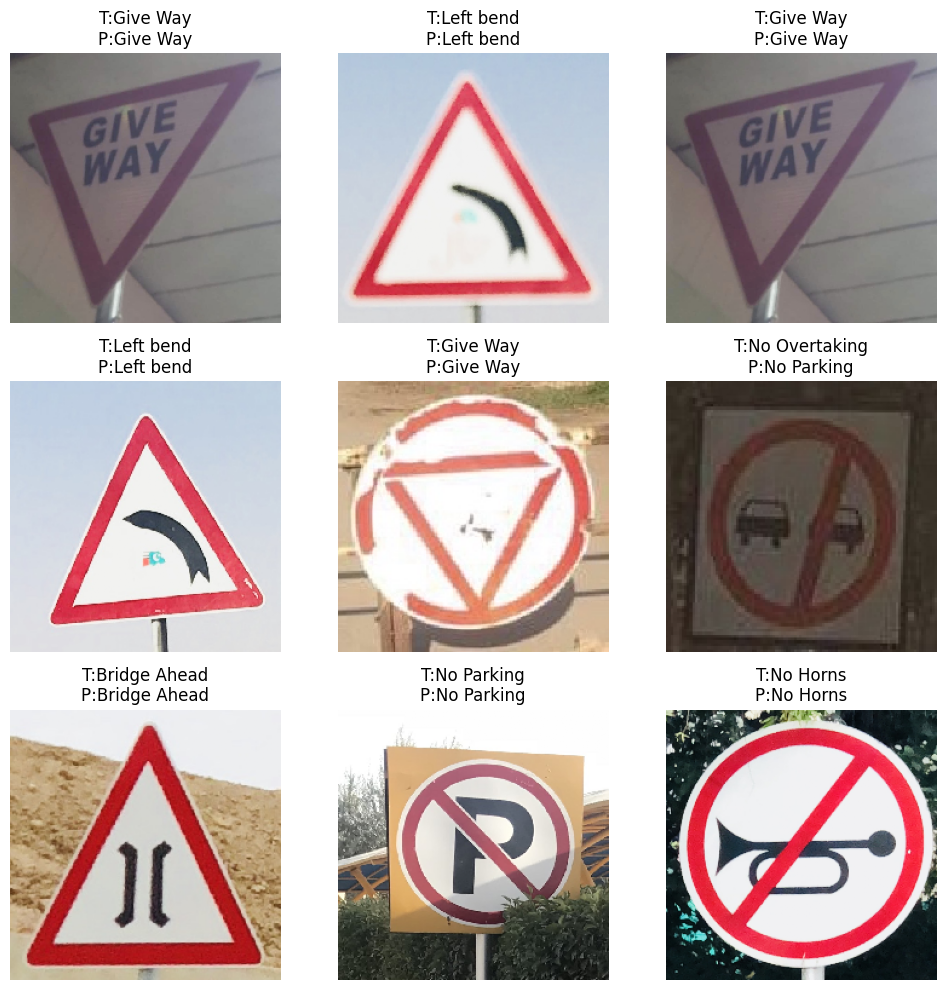

In [104]:
import random
from tensorflow.keras.preprocessing import image

# Pick 9 random test images
test_imgs, test_labels = next(test_generator)
plt.figure(figsize=(10,10))

for i in range(9):
    idx = random.randint(0, test_imgs.shape[0]-1)
    img = test_imgs[idx]
    true_label = class_names[test_labels[idx].argmax()]
    pred_label = class_names[np.argmax(model.predict(img[np.newaxis, ...]))]
    
    plt.subplot(3,3,i+1)
    plt.imshow((img+1)/2)  # undo preprocessing for display
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [106]:
model.save("/kaggle/working/traffic_sign_mobilenetv2.h5")

In [107]:
model.save("/kaggle/working/traffic_sign_mobilenetv2.keras")